<a href="https://colab.research.google.com/github/svyatoslavna/ml_hw/blob/main/log_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание: линейные модели для NLP**

## **Что будем делать?**
Мы будем предсказывать, к какой категории относится новость: про хоккей или про космос.

## **Часть 1. Практическая работа (8 баллов)**

### **1. Загрузка данных**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
import seaborn as sns

# Загружаем данные о новостях
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all',
                               categories=categories,
                               shuffle=True,
                               random_state=42)

# Создаём таблицу с данными
data = pd.DataFrame({
    'text': newsgroups.data,
    'category': newsgroups.target  # 0 = хоккей, 1 = космос
})

print("Размер данных:", data.shape)
print("\nПервые 3 текста:")
for i in range(3):
    print(f"Текст {i+1}: {data['text'][i][:100]}...")

Размер данных: (1986, 2)

Первые 3 текста:
Текст 1: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I....
Текст 2: From: epritcha@s.psych.uiuc.edu ( Evan Pritchard)
Subject: Re: div. and conf. names
Distribution: na...
Текст 3: From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)
Subject: Galileo Update - 04/29/93
Keywords: Galileo, ...


**Задание 1:**
- Сколько всего текстов в датасете?
- Выведите количество текстов в каждой категории

In [2]:
data.head()

,text,category
0,From: mccall@mksol.dseg.ti.com (fred j mccall ...,1
1,From: epritcha@s.psych.uiuc.edu ( Evan Pritcha...,0
2,From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)\...,1
3,From: mse@cc.bellcore.com (25836-michael evenc...,0
4,From: apanjabi@guvax.acc.georgetown.edu\nSubje...,0


In [3]:
print(f"Всего текстов в датасете: {len(data)}")
print(f"- Текстов про космос: {len(data[data["category"] == 1])}")
print(f"- Текстов про хоккей: {len(data[data["category"] == 0])}")

Всего текстов в датасете: 1986
- Текстов про космос: 987
- Текстов про хоккей: 999


### **2. Анализ данных**

In [4]:
data.isnull().sum() # нет пустых значений

,0
text,0
category,0


In [5]:
# Подсказка: используйте value_counts()

data['category'].value_counts() # подсчитали количество текстов в каждой категории вторым способом

,count
category,
0,999
1,987


In [6]:
round(data['category'].value_counts(normalize=True) * 100, 2) # в процентном соотноешнии

,proportion
category,
0,50.3
1,49.7


In [7]:
# проанализируем тексты по категориям по длине (в символах и в словах),
# без чистки текста

data['text_length'] = data['text'].str.len()
data['word_count'] = data['text'].str.split().str.len()

text_length_stats = round(data.groupby('category')['text_length'].describe(), 2)
word_len_stats = round(data.groupby('category')['word_count'].describe(), 2)

print("========== СРАВНЕНИЕ ДЛИН ТЕКСТОВ ПО КАТЕГОРИЯМ ==========\n")
print(f"Длина В СИМВОЛАХ:\n {text_length_stats}\n\n\n")
print(f"Длина В СЛОВАХ:\n {word_len_stats}")

# длины текстов по категориям очень сильно НЕ отличаются

========== СРАВНЕНИЕ ДЛИН ТЕКСТОВ ПО КАТЕГОРИЯМ ==========

Длина В СИМВОЛАХ:
           count     mean      std    min    25%     50%     75%      max
category                                                                
0         999.0  1853.87  3204.60  162.0  766.5  1229.0  1943.0  75154.0
1         987.0  1941.03  3334.46  166.0  811.5  1229.0  1931.5  57022.0



Длина В СЛОВАХ:
           count    mean     std   min    25%    50%    75%      max
category                                                           
0         999.0  285.78  497.31  17.0  116.0  186.0  304.0  11278.0
1         987.0  290.38  499.88  19.0  115.0  183.0  299.0   9138.0


**Вопрос:** Какая категория больше: хоккей или космос?

**Ответ:** Категория 0 - хоккей.

### **3. Очистка текста**

In [8]:
import re

def clean_text(text):
    # Ваш код здесь
    # 1. Привести текст к нижнему регистру (.lower())
    # 2. Удалить всё, кроме букв и пробелов (re.sub)
    # 3. Убрать лишние пробелы
    text = text.lower().strip()
    text = re.sub(r'[^a-zа-я\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

# Применяем функцию
data['clean_text'] = data['text'].apply(clean_text)

# Проверяем
print("До очистки:\n", data['text'][0][:100])
print("\nПосле очистки:\n", data['clean_text'][0][:100])

До очистки:
 From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.

После очистки:
 from mccall mksol dseg ti com fred j mccall subject re vandalizing the sky article i d mksol apr org


### **4. Создание признаков (векторизация)**

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

# Ваш код здесь
# 1. Создайте CountVectorizer (остановитесь на английском)
# 2. Преобразуйте тексты в числа (fit_transform)

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['clean_text'])

In [10]:
# 3. Выведите сколько слов получилось

print(f"Размер матрицы: {X.shape}")
print(f"Количество документов: {X.shape[0]}")
print(f"Количество уникальных слов: {X.shape[1]}") # признаки

Размер матрицы: (1986, 24480)
Количество документов: 1986
Количество уникальных слов: 24480


**Вопрос:** Сколько уникальных слов нашёл CountVectorizer?

**Ответ:** 24480

### **5. Разделение данных**

In [11]:
from sklearn.model_selection import train_test_split

# Цель: предсказать категорию (0 или 1)
y = data['category'] # целевая переменная

# Ваш код здесь
# Разделите данные на 80% обучение, 20% тест
# Используйте random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=data['category']
    )

print(f"Обучающих текстов: {X_train.shape[0]}")
print(f"Тестовых текстов: {X_test.shape[0]}")

Обучающих текстов: 1588
Тестовых текстов: 398


### **6. Обучение модели**

In [12]:
from sklearn.linear_model import LogisticRegression

# Ваш код здесь
# 1. Создайте модель логистической регрессии
# 2. Обучите её на обучающих данных
# 3. Сделайте предсказания для тестовых данных

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### **7. Оценка модели**

In [13]:
from sklearn.metrics import accuracy_score

# Ваш код здесь
# 1. Вычислите accuracy (точность) модели
# 2. Выведите результат в процентах

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели в процентах:({accuracy*100:.2f}%)")

Точность модели в процентах:(99.25%)


**Вопрос:** Какая точность у вашей модели? Что это значит?

**Ответ:** Точность очень высокая - 99.25% означает, что модель ошибается только в 0.75% случаев, что кажется слегка подозрительным. Скорее всего, дело в том, что задача сама по себе очень проста.

### **8. Анализ ошибок**

In [14]:
from sklearn.metrics import confusion_matrix


# Ваш код здесь
# 1. Создайте матрицу ошибок
# 2. Выведите её

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[199   1]
 [  2 196]]


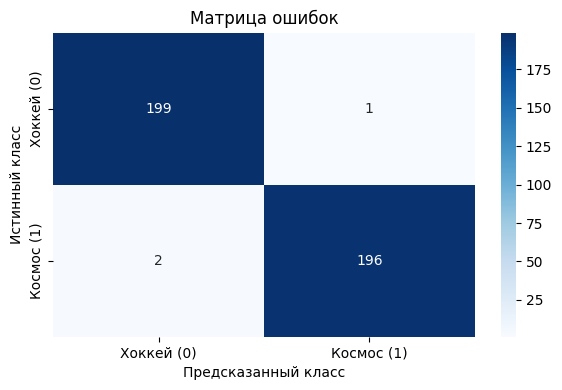

In [15]:
# БОНУС: визуализируйте матрицу ошибок
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Хоккей (0)', 'Космос (1)'],
    yticklabels=['Хоккей (0)', 'Космос (1)'],
    )
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')

plt.tight_layout()
plt.show()

**Вопрос:** Сколько текстов про космос модель приняла за хоккей?

**Ответ:** Вместо космоса предсказан хоккей - 2 случая. Вместо хоккея предсказан космос - 1 случай.